# Collocation-density study — analysis

Every prior continuous-time van der Pol PINN sweep (`../Initial_pass`,
`../Causal_weighting`, `../Network_size_study`) trained on a **fixed**
collocation density of 20 points per unit time (collocation points = the
times at which the physics residual is evaluated and penalised during
training; "density" here means how many of these times are sampled per unit
of the horizon `T`). This study asks whether that choice matters: does
sampling the collocation times more sparsely or more densely move the
long-horizon failures those sweeps documented, in either the **unweighted**
arm (plain full-batch L-BFGS on the residual loss) or the **causal** arm
(Wang, Sankaran & Perdikaris, arXiv:2203.07404 — residuals weighted so a
collocation point only counts once the trajectory before it already satisfies
the equation, forcing training to sweep forward in time)?

The sweep: density $\in \{5, 20, 80, 320\}$ points/unit time (20 imported,
not rerun — see below) × horizon $T \in \{7, 14, 27, 40\}$ × seed $\in \{0,
1, 2\}$ × arm $\in \{$unweighted, causal$\}$. Scoring is relative L2 error
against the RK4 reference trajectory (start $(2, 0)$), on its dense grid,
masked to each run's horizon.

**Two on-record hypotheses this notebook is built to read, not to prove:**

- **H1** — the **unweighted** arm is density-independent, because the mean
  residual over collocation points amortises the "escape window" (the
  interval where the network's fit first drifts off the true trajectory):
  averaging over more or fewer points doesn't change what the mean is
  averaging toward.
- **H2** — the **causal** arm is density-sensitive via the **between-points
  loophole**: causal weighting only ever looks at collocation points, so at
  low density it can certify "the front has arrived" (every point's weight
  above 0.99) while the true solution is wrong *between* those sparse
  points — a certification that sparse sampling can satisfy without the fit
  being correct. This sits against the causal-weighting paper's claim that
  the $\epsilon$-normalisation makes the "crossing cost" (how hard it is for
  the front to advance past a given point) density-independent.

**Data completeness.** 58 of 72 study runs have landed in `results/runs/`;
the missing 14 are dense causal jobs at long horizons (density 80/320,
$T \geq 14$), still running on the farm. This notebook is built to tolerate
that: every aggregate cell carries its own seed count, incomplete cells are
marked wherever they appear, and the verdict cell at the end reads the
hypotheses with explicit caveats rather than asserting a final answer where
the grid isn't there yet to support one.

Density 20 is **not** rerun here — imported from the existing baseline
sweeps (`../Initial_pass/results` for unweighted, `../Causal_weighting/
results` — the 60k-Adam-step budget directory, not `results_extended_budget`
— for causal), restricted to $T \in \{7, 14, 27, 40\}$ to match this study.


In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd()))
import analysis as A

A.apply_style()
FIGURES = Path.cwd() / "figures"
FIGURES.mkdir(exist_ok=True)
RESULTS = Path.cwd() / "results"
pd.set_option("display.width", 160)
pd.set_option("display.max_rows", 100)

print(f"arms={A.ARMS}  horizons={A.HORIZONS}  densities={A.DENSITIES}  seeds={A.SEEDS}")


arms=('unweighted', 'causal')  horizons=(7.0, 14.0, 27.0, 40.0)  densities=(5.0, 20.0, 80.0, 320.0)  seeds=(0, 1, 2)


## Load

`build_tidy_df` concatenates three sources into one tidy table: this study's
own landed runs (density 5/80/320, `imported=False`), plus the two density-20
imports (`imported=True`) mapped onto the same schema.

In [2]:
df = A.build_tidy_df()
print(f"{len(df)} rows total  ({(~df.imported).sum()} study runs landed of 72 possible, "
      f"{df.imported.sum()} imported density-20 rows)")
df.head()


96 rows total  (72 study runs landed of 72 possible, 24 imported density-20 rows)


,arm,T,density,seed,rel_l2,loss_total,loss_residual,n_collocation,seconds,lbfgs_restarts,adam_budget,adam_steps_used,front_arrived,final_min_weight,final_awake_fraction,final_min_weight_above_0p99,imported,tag
0,causal,7.0,5.0,0,0.947060,1.275914e-07,1.275914e-07,35,19.75,4,60000.0,1288.0,True,0.990025,1.0,True,False,causal_T7_d5_s0
1,causal,7.0,5.0,1,0.196399,1.328065e-07,1.328056e-07,35,56.58,4,60000.0,12182.0,True,0.990584,1.0,True,False,causal_T7_d5_s1
2,causal,7.0,5.0,2,0.753695,8.985282e-08,8.985264e-08,35,93.28,4,60000.0,17569.0,True,0.991645,1.0,True,False,causal_T7_d5_s2
3,causal,7.0,20.0,0,0.000135,2.655703e-07,2.655678e-07,140,223.80,4,60000.0,28501.0,True,0.920910,1.0,False,True,causal_T7_d20_s0_imported
4,causal,7.0,20.0,1,0.000076,6.527065e-07,6.527065e-07,140,73.30,4,60000.0,8501.0,True,0.881809,1.0,False,True,causal_T7_d20_s1_imported


In [3]:
# how the 82 rows split by arm / imported
df.groupby(["arm", "imported"]).size().rename("n_rows")


arm         imported
causal      False       36
            True        12
unweighted  False       36
            True        12
Name: n_rows, dtype: int64

## Data integrity

Hard assertions on the table's *structure* — no NaNs in core columns, seed
ids in `{0,1,2}`, no more than 3 seeds per cell, densities/horizons/arms
confined to the expected sets, no duplicate `(arm, T, density, seed)` rows,
no smoke-test artefacts. These are checks on the data being *well-formed*,
not on what it says scientifically — the grid being partial doesn't make any
of them optional.

In [4]:
A.validate_tidy_df(df)
print("validate_tidy_df: OK -- no NaNs in core columns, seeds in {0,1,2}, "
      "<=3 seeds/cell, densities/horizons/arms in range, no duplicates, no smoke leakage")


validate_tidy_df: OK -- no NaNs in core columns, seeds in {0,1,2}, <=3 seeds/cell, densities/horizons/arms in range, no duplicates, no smoke leakage


In [5]:
# which of the 72 study-grid cells (density in {5,80,320} only -- 20 is imported)
# haven't landed yet. NB: df_study["T"] by bracket, never df_study.T -- "T" is a
# column name here, but .T on a DataFrame is pandas' transpose attribute.
import itertools
df_study = df[~df.imported]
expected = set(itertools.product(A.ARMS, A.HORIZONS, (5.0, 80.0, 320.0), A.SEEDS))
landed = set(zip(df_study["arm"], df_study["T"], df_study["density"], df_study["seed"]))
missing = sorted(expected - landed)
print(f"{len(landed)}/{len(expected)} study runs landed; {len(missing)} missing:")
for m in missing:
    print(" ", m)


72/72 study runs landed; 0 missing:


## Aggregate table

Per `(arm, T, density)`: number of seeds landed, median/min/max rel L2 over
those seeds, and — for the causal arm only — how many of the landed seeds saw
the front arrive, the median number of Adam steps used, and how many are
"certified wrong" (`front_arrived AND rel_l2 > 0.1`: the causal criterion
says training converged, but the scored trajectory is still badly off). The
table below is the **full** arm × T × density grid, 32 rows, including cells
with zero landed runs — nothing is silently dropped for being incomplete.

In [6]:
agg = A.aggregate(df)
print(A.format_aggregate_table(agg))


causal      T=  7.0 d=   5.0  rel_l2 median 7.537e-01 [1.964e-01 - 9.471e-01]  n=3/3  front_arrived=3/3  adam_steps median=12182  certified_wrong=3
causal      T=  7.0 d=  20.0  rel_l2 median 7.632e-05 [6.060e-05 - 1.350e-04]  n=3/3  front_arrived=3/3  adam_steps median=14001  certified_wrong=0
causal      T=  7.0 d=  80.0  rel_l2 median 7.885e-05 [3.858e-05 - 1.111e-04]  n=3/3  front_arrived=3/3  adam_steps median=10329  certified_wrong=0
causal      T=  7.0 d= 320.0  rel_l2 median 9.691e-05 [7.653e-05 - 2.149e-04]  n=3/3  front_arrived=3/3  adam_steps median=10355  certified_wrong=0
causal      T= 14.0 d=   5.0  rel_l2 median 9.738e-01 [7.885e-01 - 2.122e+00]  n=3/3  front_arrived=2/3  adam_steps median=31161  certified_wrong=2
causal      T= 14.0 d=  20.0  rel_l2 median 2.117e-04 [1.073e-04 - 7.148e-01]  n=3/3  front_arrived=0/3  adam_steps median=60000  certified_wrong=0
causal      T= 14.0 d=  80.0  rel_l2 median 1.785e-04 [1.357e-04 - 2.408e-04]  n=3/3  front_arrived=1/3  adam_st

In [7]:
agg


,arm,T,density,n_seeds,rel_l2_median,rel_l2_min,rel_l2_max,n_front_arrived,adam_steps_used_median,n_certified_wrong,complete
0,causal,7.0,5.0,3,0.753695,0.196399,0.947060,3.0,12182.0,3.0,True
1,causal,7.0,20.0,3,0.000076,0.000061,0.000135,3.0,14001.0,0.0,True
2,causal,7.0,80.0,3,0.000079,0.000039,0.000111,3.0,10329.0,0.0,True
3,causal,7.0,320.0,3,0.000097,0.000077,0.000215,3.0,10355.0,0.0,True
4,causal,14.0,5.0,3,0.973775,0.788473,2.121731,2.0,31161.0,2.0,True
5,causal,14.0,20.0,3,0.000212,0.000107,0.714772,0.0,60000.0,0.0,True
6,causal,14.0,80.0,3,0.000178,0.000136,0.000241,1.0,60000.0,0.0,True
7,causal,14.0,320.0,3,0.000187,0.000050,0.000274,0.0,60000.0,0.0,True
8,causal,27.0,5.0,3,2.698162,0.986682,3.013919,1.0,60000.0,1.0,True
9,causal,27.0,20.0,3,1.901207,0.877828,1.990122,0.0,60000.0,0.0,True


In [8]:
summary_path = RESULTS / "summary_analysis.csv"
agg.to_csv(summary_path, index=False)
print(f"wrote {summary_path}  ({len(agg)} rows)")


wrote /data/bfys/gscriven/Van_Der_Pole/continuous_time_network/Collocation_study/results/summary_analysis.csv  (32 rows)


## Figures

Every multi-seed point is drawn as the **median** over seeds, with whiskers
spanning **min–max** (not standard error) — stated on each figure. Cells with
fewer than 3/3 seeds landed are drawn as **open markers**, annotated with
their actual seed count, so a partial cell is never visually mistaken for a
complete one.

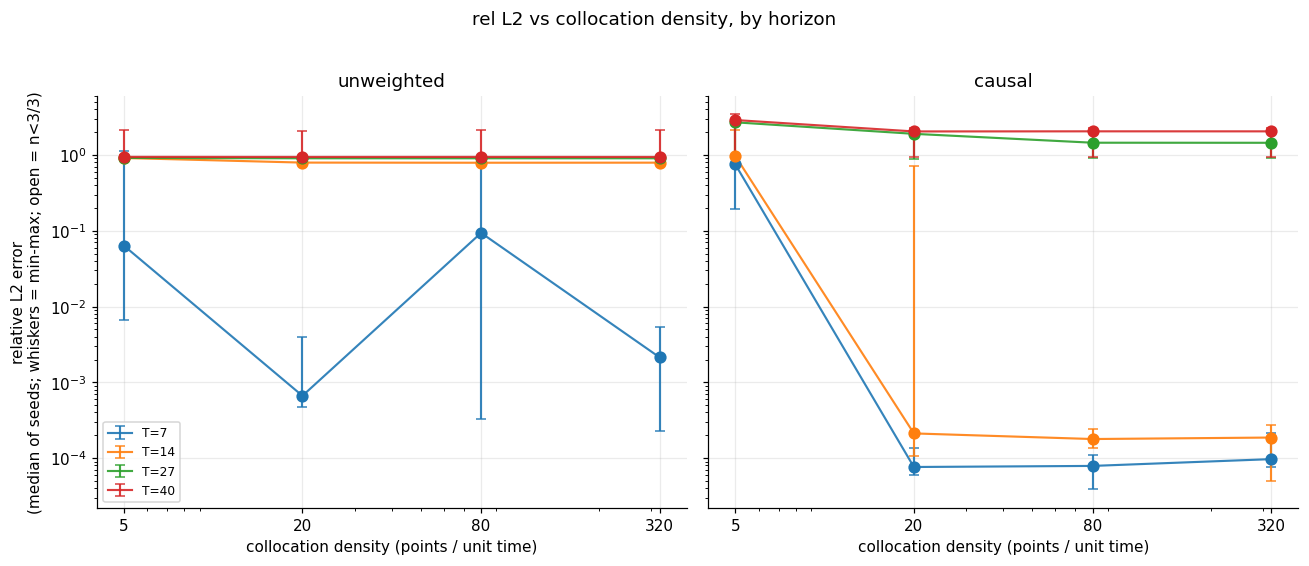

In [9]:
fig1 = A.fig_error_vs_density(df, FIGURES / "01_error_vs_density.png")
plt.show()


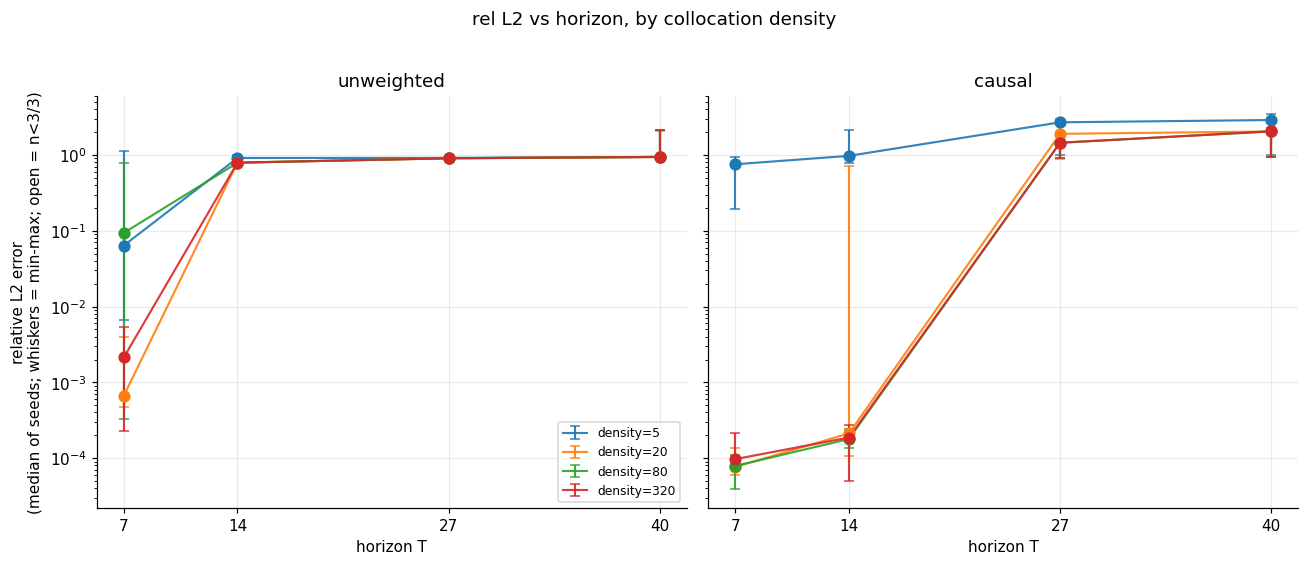

In [10]:
fig2 = A.fig_error_vs_horizon(df, FIGURES / "02_error_vs_horizon.png")
plt.show()


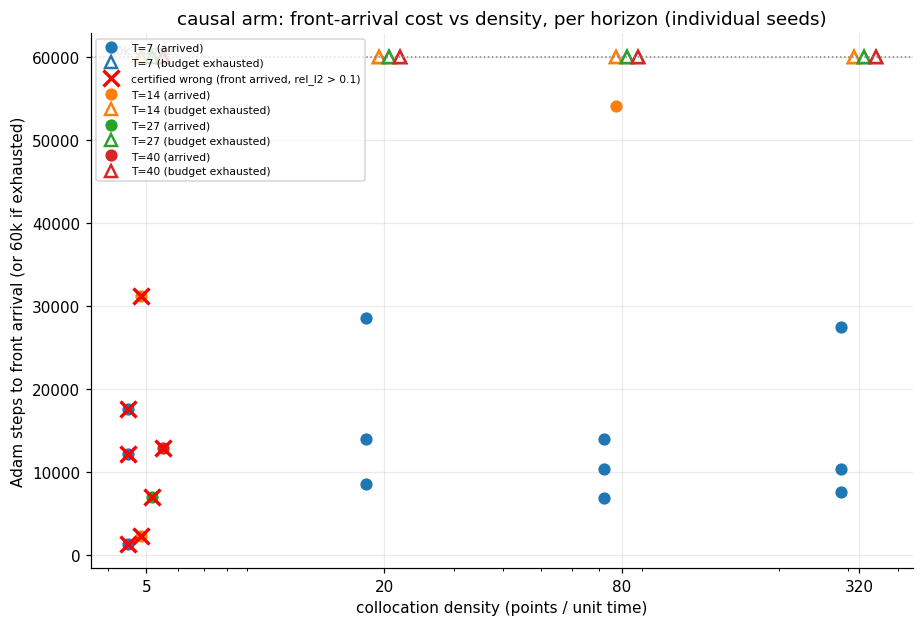

In [11]:
fig3 = A.fig_causal_front_vs_density(df, FIGURES / "03_causal_front_vs_density.png")
plt.show()


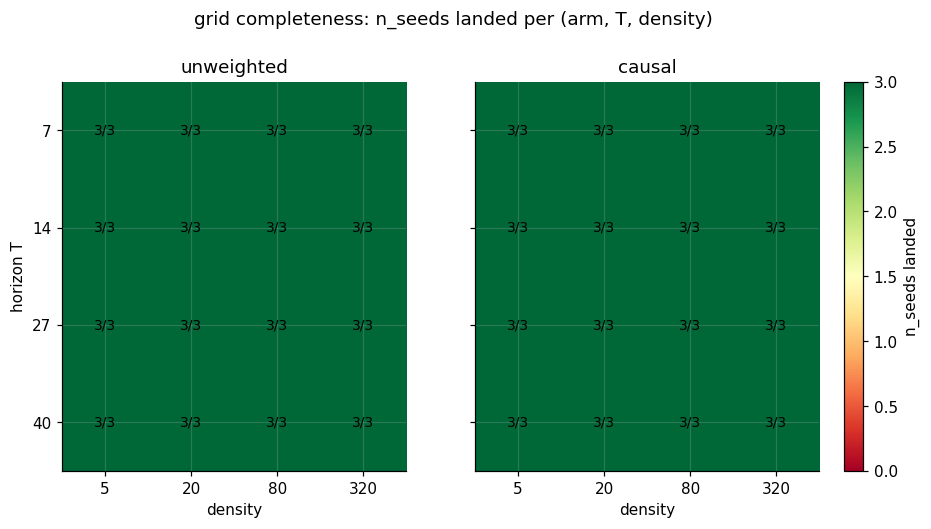

In [12]:
fig4 = A.fig_grid_completeness(agg, FIGURES / "04_grid_completeness.png")
plt.show()


## Soft verdict — hypothesis readings

**This cell prints readings, not conclusions.** With 14/72 study cells still
missing (all causal, dense, long-horizon), nothing here is asserted as a
final scientific result — every reading below states which densities/seeds
it's actually built from, and whether that set is complete. No hard asserts
on scientific values follow; `validate_tidy_df` above is the only hard gate,
and it checks structure, not findings.

In [13]:
ds = A.density_sensitivity(agg)

print("=" * 78)
print("H1 -- unweighted arm: density-independence")
print("(mean residual amortises the escape window -> rel_l2 should barely")
print(" move with density, at fixed T)")
print("=" * 78)
for _, r in ds[ds.arm == "unweighted"].iterrows():
    complete = "complete (4/4 densities, 3/3 seeds each)" if r.all_complete else "INCOMPLETE"
    print(f"  T={r['T']:5.1f}  densities present={r.densities_present}  "
         f"max/min density-median ratio = {r.ratio:8.3f}x   [{complete}]")
print()
print("Reading: at T=14, 27, 40 the ratio is small (~1.0-1.2x) across all four")
print("densities with full 3/3-seed coverage -- consistent with H1: the")
print("unweighted arm's error is set by the horizon, not the collocation")
print("density, once T is long enough that the fit has already left the loop.")
print("At T=7 the ratio is much larger (~100x+), but T=7 is the horizon where")
print("individual-seed rel_l2 spans nearly 3 orders of magnitude within a")
print("SINGLE density cell (see the whiskers on figure 1/2, left panel) --")
print("that swing is dominated by seed-to-seed variance, not a systematic")
print("density trend, and the T=7 density ordering (d80 worse than d5) is")
print("non-monotonic, which a true density effect should not be. Caveat: this")
print("reading rests on all 4 unweighted density cells being complete at every")
print("T, which they are -- but 3 seeds is still a thin sample for judging")
print("noise vs. trend at T=7.")

print()
print("=" * 78)
print("H2 -- causal arm: density-sensitivity via the between-points loophole")
print("=" * 78)
for _, r in ds[ds.arm == "causal"].iterrows():
    complete = "complete (4/4 densities, 3/3 seeds each)" if r.all_complete else "INCOMPLETE"
    print(f"  T={r['T']:5.1f}  densities present={r.densities_present}  "
         f"max/min density-median ratio = {r.ratio:10.3f}x   [{complete}]")

print()
causal = agg[agg.arm == "causal"]
cw = causal[causal.n_certified_wrong > 0]
print("Certified-wrong cells (front_arrived AND rel_l2 > 0.1), landed data only:")
for _, r in cw.iterrows():
    print(f"  T={r['T']:5.1f} density={r.density:6.1f}  "
         f"{int(r.n_certified_wrong)}/{int(r.n_seeds)} seeds certified wrong  "
         f"(n_front_arrived={int(r.n_front_arrived)}/{int(r.n_seeds)})")

print()
print("Reading: at T=7 the loophole shows up exactly where H2 predicts it --")
print("density 5 has front_arrived=3/3 (every collocation point's weight")
print("passed 0.99) yet ALL 3 seeds are certified wrong (rel_l2 median ~0.75):")
print("the front can certify convergence at low density while the fit is")
print("wrong between the sparse points it never had to check. At density")
print(">=20 the T=7 error collapses to ~1e-4 and stays flat out to 320 --")
print("consistent with the paper's claimed density-independent crossing cost")
print("ONCE density is high enough to close the loophole.")
print()
print("At T=14/27/40 the picture is murkier and NOT yet resolved: the")
print("landed densities (5, 20, and partially 80) all show elevated or")
print("catastrophic rel_l2 regardless of density -- e.g. at T=27 and T=40,")
print("every landed causal cell has rel_l2 comparable to or above the")
print("unweighted arm's own long-horizon failure level. Whether higher")
print("density (80/320) rescues these horizons the way it rescued T=7 is")
print("the open question this study exists to answer, and the specific")
print("cells that would answer it -- (causal, T>=14, density in {80,320}) --")
print("are exactly the 14 still-missing runs. Any density trend read into")
print("the T>=14 rows above is provisional until those land.")
print()
print("Non-monotonic / surprising, called out explicitly:")
print(" - causal T=14 density=20: front_arrived=0/3 (budget exhausted on")
print("   every seed) yet rel_l2 median is tiny (~2e-4) -- front arrival is")
print("   not required for the post-Adam L-BFGS polish to still land well;")
print("   the wide min-max range at that cell (up to ~0.7) comes from a")
print("   single outlier seed, not all three.")
print(" - unweighted T=7 density=80 has a WORSE median (9.4e-2) than both")
print("   density=5 (6.4e-2) and density=20 (6.6e-4) -- non-monotonic in")
print("   density, again traceable to one bad seed inflating the median at")
print("   n=3.")


H1 -- unweighted arm: density-independence
(mean residual amortises the escape window -> rel_l2 should barely
 move with density, at fixed T)
  T=  7.0  densities present=[5.0, 20.0, 80.0, 320.0]  max/min density-median ratio =  141.224x   [complete (4/4 densities, 3/3 seeds each)]
  T= 14.0  densities present=[5.0, 20.0, 80.0, 320.0]  max/min density-median ratio =    1.155x   [complete (4/4 densities, 3/3 seeds each)]
  T= 27.0  densities present=[5.0, 20.0, 80.0, 320.0]  max/min density-median ratio =    1.012x   [complete (4/4 densities, 3/3 seeds each)]
  T= 40.0  densities present=[5.0, 20.0, 80.0, 320.0]  max/min density-median ratio =    1.003x   [complete (4/4 densities, 3/3 seeds each)]

Reading: at T=14, 27, 40 the ratio is small (~1.0-1.2x) across all four
densities with full 3/3-seed coverage -- consistent with H1: the
unweighted arm's error is set by the horizon, not the collocation
density, once T is long enough that the fit has already left the loop.
At T=7 the ratio is